In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import import_ipynb
from ai_models.simca import SIMCAModel, SIMCAClassModel
from itertools import product
from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
%matplotlib inline

Replicate_011_20251119 – NIR: 10 files
Replicate_011_20251119 NIR shape: (10, 228)
Replicate_011_20251119 – VIS: 10 files
Replicate_011_20251119 VIS shape: (10, 288)
Replicate_011_20251119 – FLUO: 10 files
Replicate_011_20251119 FLUO shape: (10, 288)
Replicate_012_20251119 – NIR: 10 files
Replicate_012_20251119 NIR shape: (10, 228)
Replicate_012_20251119 – VIS: 10 files
Replicate_012_20251119 VIS shape: (10, 288)
Replicate_012_20251119 – FLUO: 10 files
Replicate_012_20251119 FLUO shape: (10, 288)
Replicate_021_20251119 – NIR: 10 files
Replicate_021_20251119 NIR shape: (10, 228)
Replicate_021_20251119 – VIS: 10 files
Replicate_021_20251119 VIS shape: (10, 288)
Replicate_021_20251119 – FLUO: 10 files
Replicate_021_20251119 FLUO shape: (10, 288)
Replicate_022_20251119 – NIR: 10 files
Replicate_022_20251119 NIR shape: (10, 228)
Replicate_022_20251119 – VIS: 10 files
Replicate_022_20251119 VIS shape: (10, 288)
Replicate_022_20251119 – FLUO: 10 files
Replicate_022_20251119 FLUO shape: (10, 2

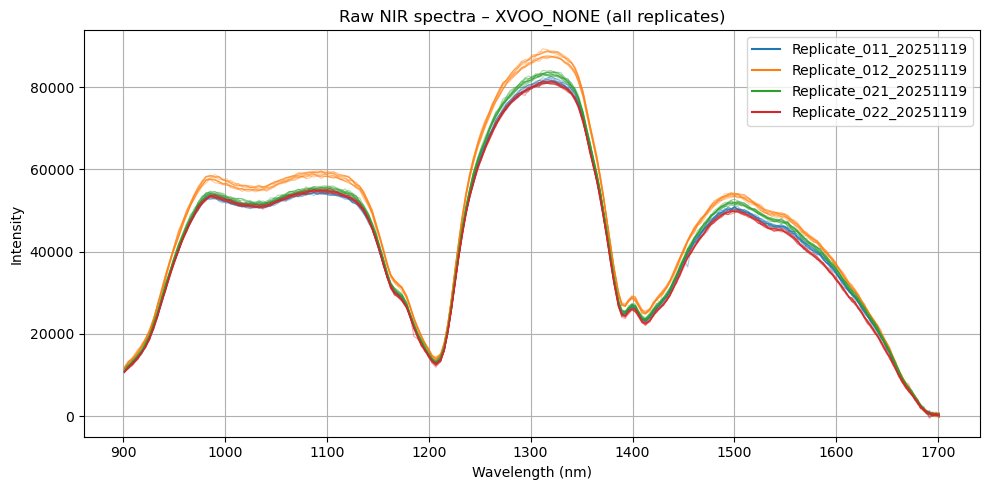

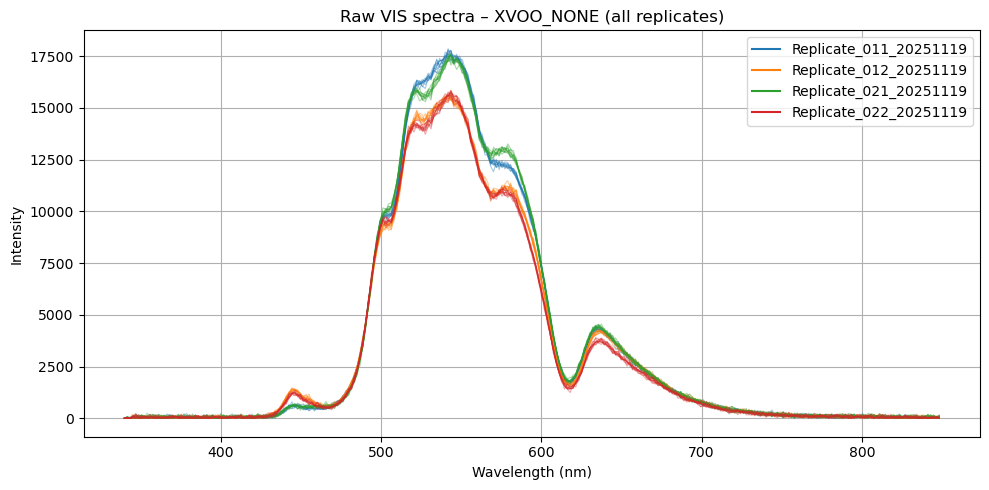

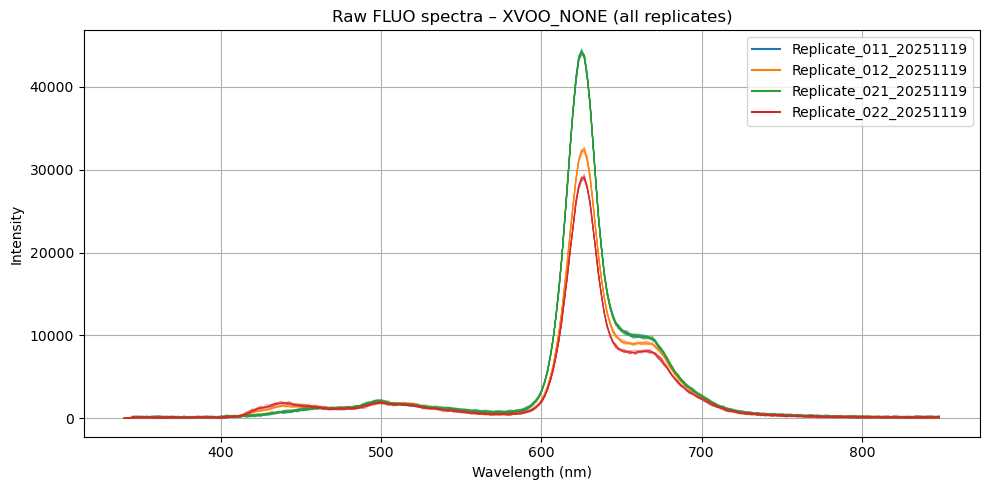

In [2]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    r"data/Replicate_012/Replicate_012_20251119",
    r"data/Replicate_021/Replicate_021_20251119",
    r"data/Replicate_022/Replicate_022_20251119",
    # r"data/Replicate_011/Replicate_011_20251230",
]

spectra_types = ["NIR", "VIS", "FLUO"]

xvoo_none_spectra = {spec: {} for spec in spectra_types}
wavelengths_dict = {spec: {} for spec in spectra_types}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)

    for spec_type in spectra_types:
        spec_path = os.path.join(base_folder, "xvoo_none", spec_type)

        if not os.path.exists(spec_path):
            print(f"Warning: {spec_path} does not exist, skipping...")
            continue

        files = sorted(glob.glob(os.path.join(spec_path, "*.csv")))
        print(f"{rep_name} – {spec_type}: {len(files)} files")

        spectra = []

        for i, fpath in enumerate(files):
            df = pd.read_csv(fpath)

            if i == 0:
                wavelengths_dict[spec_type][rep_name] = df.iloc[:, 0].values
            else:
                assert np.allclose(
                    wavelengths_dict[spec_type][rep_name],
                    df.iloc[:, 0].values
                ), f"Wavelength mismatch in {rep_name} ({spec_type})"

            spectra.append(df.iloc[:, 1].values)

        xvoo_none_spectra[spec_type][rep_name] = np.array(spectra)

        print(
            f"{rep_name} {spec_type} shape:",
            xvoo_none_spectra[spec_type][rep_name].shape
        )
        
rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for spec_type in ["NIR", "VIS", "FLUO"]:

    plt.figure(figsize=(10, 5))

    for i, (rep_name, spectra) in enumerate(xvoo_none_spectra[spec_type].items()):
        wl = wavelengths_dict[spec_type][rep_name]

        for spec in spectra:
            plt.plot(
                wl,
                spec,
                color=rep_colors[i],
                alpha=0.4,
                lw=0.8
            )

        plt.plot([], [], color=rep_colors[i], label=rep_name)

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity")
    plt.title(f"Raw {spec_type} spectra – XVOO_NONE (all replicates)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Replicate_011_20251119 | NIR WR shape: (228, 2)
Replicate_011_20251119 | VIS WR shape: (288, 2)
Replicate_011_20251119 | FLUO WR shape: (288, 2)
Replicate_012_20251119 | NIR WR shape: (228, 2)
Replicate_012_20251119 | VIS WR shape: (288, 2)
Replicate_012_20251119 | FLUO WR shape: (288, 2)
Replicate_021_20251119 | NIR WR shape: (228, 2)
Replicate_021_20251119 | VIS WR shape: (288, 2)
Replicate_021_20251119 | FLUO WR shape: (288, 2)
Replicate_022_20251119 | NIR WR shape: (228, 2)
Replicate_022_20251119 | VIS WR shape: (288, 2)
Replicate_022_20251119 | FLUO WR shape: (288, 2)


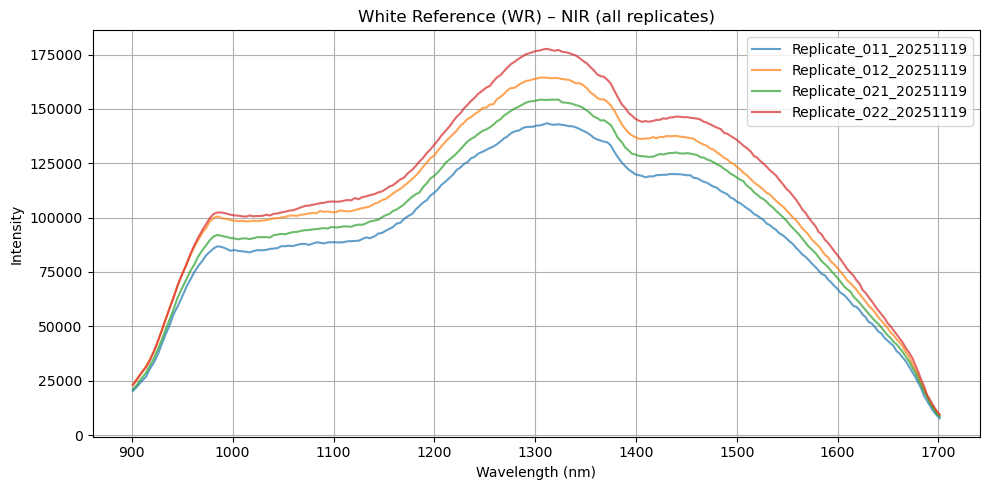

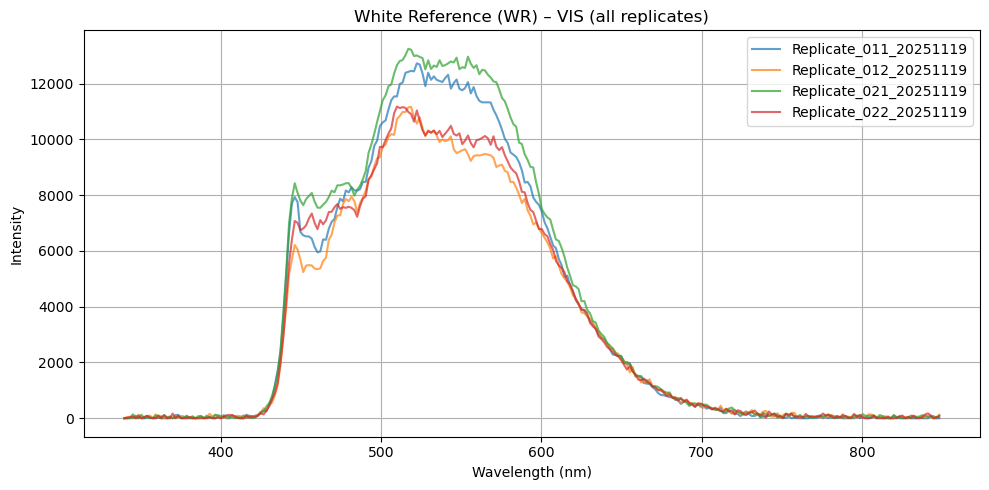

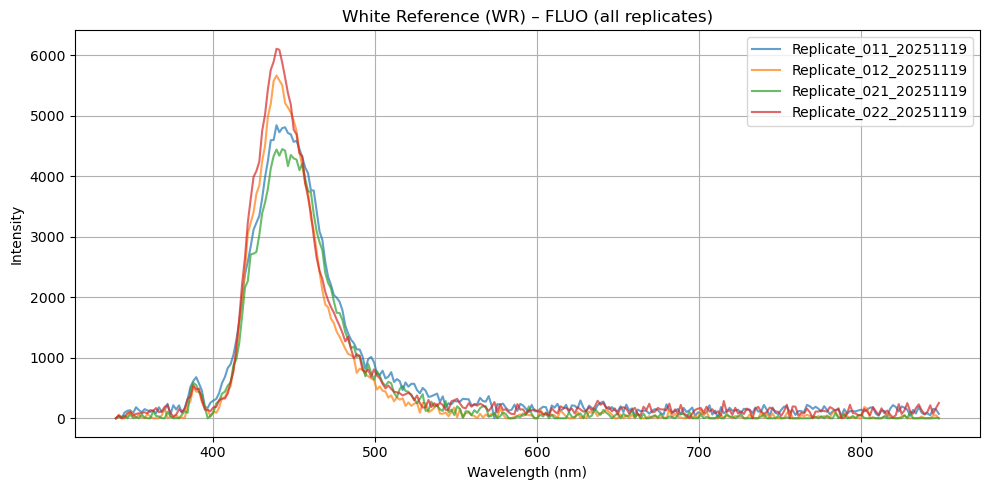

In [3]:
wr_dict = {spec: {} for spec in spectra_types}
wavelengths_wr_dict = {spec: {} for spec in spectra_types}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)

    for spec_type in spectra_types:
        wr_path = os.path.join(base_folder, "wr", f"{spec_type}_WR.csv")

        if not os.path.exists(wr_path):
            print(f"Warning: {spec_type} WR does not exist for {rep_name}")
            continue

        wr_df = pd.read_csv(wr_path)

        wl_wr = wr_df.iloc[:, 0].values
        I_wr = wr_df.iloc[:, 1].values

        wavelengths_wr_dict[spec_type][rep_name] = wl_wr
        wr_dict[spec_type][rep_name] = I_wr

        print(f"{rep_name} | {spec_type} WR shape:", wr_df.shape)
for spec_type in spectra_types:
    plt.figure(figsize=(10, 5))

    for i, (rep_name, I_wr) in enumerate(wr_dict[spec_type].items()):
        wl_wr = wavelengths_wr_dict[spec_type][rep_name]

        plt.plot(
            wl_wr,
            I_wr,
            alpha=0.7,
            label=rep_name
        )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity")
    plt.title(f"White Reference (WR) – {spec_type} (all replicates)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Replicate_011_20251119 | NIR normalized shape: (10, 228) (filter=False)
Replicate_012_20251119 | NIR normalized shape: (10, 228) (filter=False)
Replicate_021_20251119 | NIR normalized shape: (10, 228) (filter=False)
Replicate_022_20251119 | NIR normalized shape: (10, 228) (filter=False)
Replicate_011_20251119 | VIS normalized shape: (10, 288) (filter=True)
Replicate_012_20251119 | VIS normalized shape: (10, 288) (filter=True)
Replicate_021_20251119 | VIS normalized shape: (10, 288) (filter=True)
Replicate_022_20251119 | VIS normalized shape: (10, 288) (filter=True)
Replicate_011_20251119 | FLUO: copied raw spectra (no normalization)
Replicate_012_20251119 | FLUO: copied raw spectra (no normalization)
Replicate_021_20251119 | FLUO: copied raw spectra (no normalization)
Replicate_022_20251119 | FLUO: copied raw spectra (no normalization)


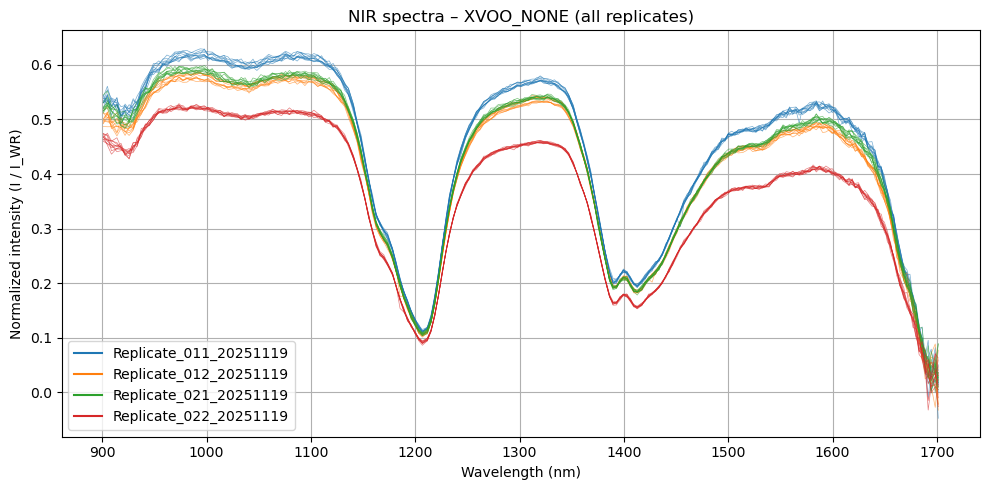

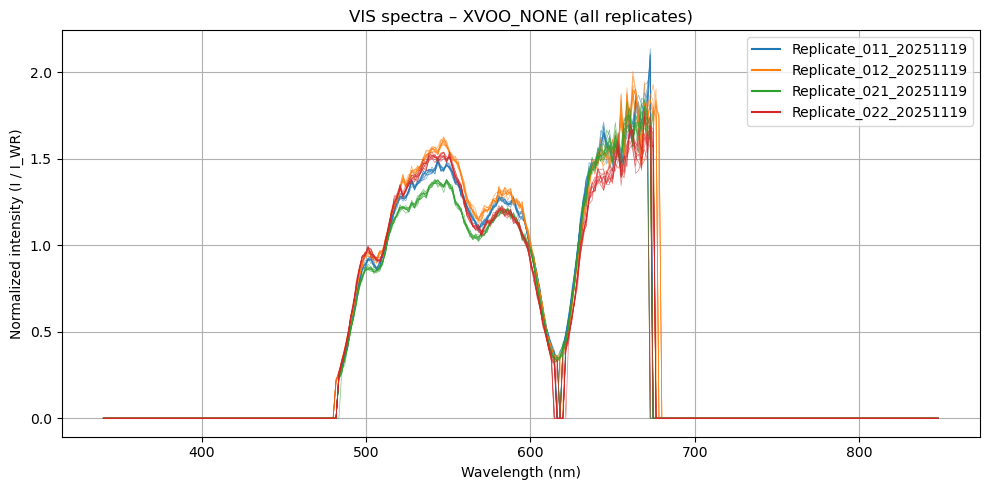

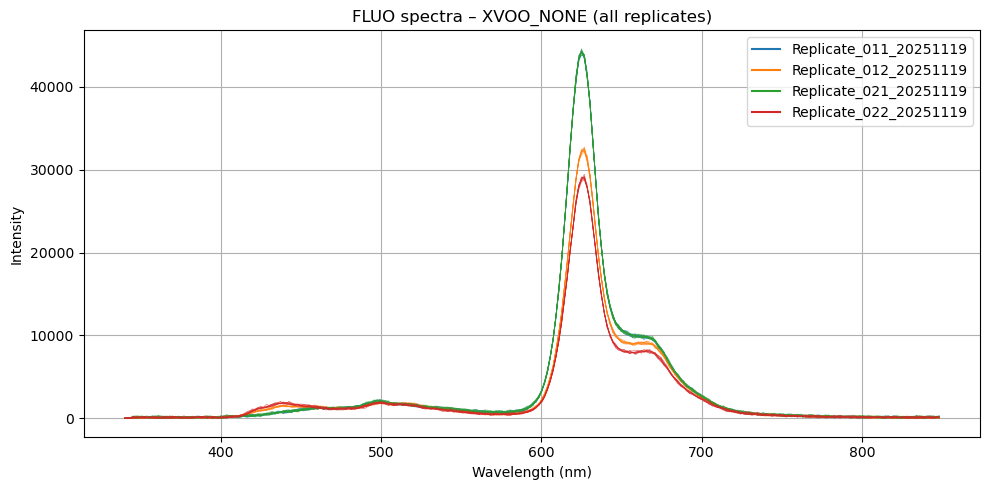

In [4]:
epsilon = 1e-10

xvoo_none_norm = {spec: {} for spec in spectra_types}

for spec_type in spectra_types:
    for rep_name, spectra in xvoo_none_spectra[spec_type].items():

        if spec_type == "FLUO":
            xvoo_none_norm[spec_type][rep_name] = spectra.copy()
            print(f"{rep_name} | {spec_type}: copied raw spectra (no normalization)")
            continue

        if rep_name not in wr_dict[spec_type]:
            print(f"Skipping {rep_name} – no {spec_type} WR")
            continue

        wr = wr_dict[spec_type][rep_name]

        assert spectra.shape[1] == wr.shape[0], \
            f"Shape mismatch {spec_type} for {rep_name}"

        if spec_type == "VIS":
            use_filter = True
        elif spec_type == "NIR":
            use_filter = False

        if use_filter:
            max_ = np.max(spectra)
            to_filter = spectra < 0.1 * max_

        spectra_norm = spectra / (wr + epsilon)

        if use_filter:
            spectra_norm[to_filter] = 0

        xvoo_none_norm[spec_type][rep_name] = spectra_norm

        print(
            f"{rep_name} | {spec_type} normalized shape:",
            spectra_norm.shape,
            f"(filter={use_filter})"
        )
for spec_type in spectra_types:
    plt.figure(figsize=(10, 5))

    for i, (rep_name, spectra) in enumerate(
        xvoo_none_norm[spec_type].items()
    ):
        wl = wavelengths_dict[spec_type][rep_name]

        for spec in spectra:
            plt.plot(
                wl,
                spec,
                color=rep_colors[i],
                alpha=0.6,
                lw=0.5
            )

        plt.plot([], [], color=rep_colors[i], label=rep_name)

    ylabel = (
        "Intensity" if spec_type == "FLUO"
        else "Normalized intensity (I / I_WR)"
    )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel(ylabel)
    plt.title(f"{spec_type} spectra – XVOO_NONE (all replicates)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [5]:
for spec_type in spectra_types:
    print(f"\n{spec_type} normalized spectra shapes per replicate:")
    for rep_name, spectra in xvoo_none_norm[spec_type].items():
        print(f"  {rep_name}: {spectra.shape}")


NIR normalized spectra shapes per replicate:
  Replicate_011_20251119: (10, 228)
  Replicate_012_20251119: (10, 228)
  Replicate_021_20251119: (10, 228)
  Replicate_022_20251119: (10, 228)

VIS normalized spectra shapes per replicate:
  Replicate_011_20251119: (10, 288)
  Replicate_012_20251119: (10, 288)
  Replicate_021_20251119: (10, 288)
  Replicate_022_20251119: (10, 288)

FLUO normalized spectra shapes per replicate:
  Replicate_011_20251119: (10, 288)
  Replicate_012_20251119: (10, 288)
  Replicate_021_20251119: (10, 288)
  Replicate_022_20251119: (10, 288)


In [6]:
X_none_fused_list = []
y_none_list = []

for rep_name in xvoo_none_norm["NIR"].keys():
    nir = xvoo_none_norm["NIR"][rep_name]
    vis = xvoo_none_norm["VIS"][rep_name]
    fluo = xvoo_none_norm["FLUO"][rep_name]

    assert nir.shape[0] == vis.shape[0] == fluo.shape[0], \
        f"Sample count mismatch in {rep_name}"

    n_samples = nir.shape[0]

    for i in range(n_samples):
        fused_sample = np.concatenate([
            nir[i],
            vis[i],
            fluo[i]
        ])
        X_none_fused_list.append(fused_sample)
        y_none_list.append("XVOO_NONE")

X_none_fused = np.array(X_none_fused_list)
y_none = np.array(y_none_list)

print("X_none_fused shape:", X_none_fused.shape)
print("y_none shape:", y_none.shape)

X_none_fused shape: (40, 804)
y_none shape: (40,)


In [7]:
github_path = Path.home() / "Documents/Github"
ai_spectra = github_path / "aiSpectra" / "data"

datasets = [
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_oo50",
                     "xvoo_oo100", "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251230",
        "mixtures": ["xvoo_lso10", "xvoo_lso20", "xvoo_lso30", "xvoo_lso40",
                     "xvoo_lso60", "xvoo_lso70", "xvoo_lso80", "xvoo_lso90",
                     "xvoo_lso100", "xvoo_none", "xvoo_oo90"]
    },
    {
        "base_folder": ai_spectra / "Replicate_012/Replicate_012_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_012/Replicate_012_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
    {
        "base_folder": ai_spectra / "Replicate_021/Replicate_021_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_022/Replicate_022_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    }
]

In [8]:
epsilon = 1e-10

mix_spectra_norm = {spec: [] for spec in spectra_types}
mix_labels = []

for ds in datasets:
    base_folder = ds["base_folder"]
    mixtures = ds["mixtures"]

    wr_files = {
        "NIR": os.path.join(base_folder, "wr", "NIR_WR.csv"),
        "VIS": os.path.join(base_folder, "wr", "VIS_WR.csv")
    }

    wr_dict_mix = {}
    for spec_type in ["NIR", "VIS"]:
        wr_df = pd.read_csv(wr_files[spec_type])
        wr_dict_mix[spec_type] = wr_df.iloc[:, 1].values

    print(f"\nUčitavam dataset iz: {base_folder}")

    for mix in mixtures:
        for spec_type in spectra_types:
            spec_folder = os.path.join(base_folder, mix, spec_type)

            if not os.path.exists(spec_folder):
                print(f"Upozorenje: folder ne postoji {spec_folder}, preskačem...")
                continue

            files = sorted([f for f in os.listdir(spec_folder) if f.endswith(".csv")])

            for f in files:
                df = pd.read_csv(os.path.join(spec_folder, f))
                spectrum = df.iloc[:, 1].values

                if spec_type == "FLUO":
                    spectrum_norm = spectrum.copy()
                elif spec_type in ["VIS", "NIR"]:
                    wr = wr_dict_mix[spec_type]
                    assert spectrum.shape[0] == wr.shape[0], \
                        f"Shape mismatch {spec_type} for {f}"

                    use_filter = spec_type == "VIS"

                    if use_filter:
                        max_ = np.max(spectrum)
                        to_filter = spectrum < 0.1 * max_

                    spectrum_norm = spectrum / (wr + epsilon)

                    if use_filter:
                        spectrum_norm[to_filter] = 0

                mix_spectra_norm[spec_type].append(spectrum_norm)

                if spec_type == "NIR":
                    mix_labels.append(mix)

for spec_type in spectra_types:
    mix_spectra_norm[spec_type] = np.array(mix_spectra_norm[spec_type])

mix_labels = np.array(mix_labels)

print("\nShapes of normalized spectra by type:")
for spec_type in spectra_types:
    print(f"{spec_type}: {mix_spectra_norm[spec_type].shape}")

print("Labels shape:", mix_labels.shape)
print("Unique classes:", np.unique(mix_labels))


Učitavam dataset iz: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_011/Replicate_011_20251119

Učitavam dataset iz: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_011/Replicate_011_20251205

Učitavam dataset iz: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_011/Replicate_011_20251230

Učitavam dataset iz: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_012/Replicate_012_20251119

Učitavam dataset iz: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_012/Replicate_012_20251205

Učitavam dataset iz: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_021/Replicate_021_20251119

Učitavam dataset iz: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_022/Replicate_022_20251119

Shapes of normalized spectra by type:
NIR: (1010, 228)
VIS: (1010, 288)
FLUO: (1010, 288)
Labels shape: (1010,)
Unique classes: ['xvoo_lso10' 'xvoo_lso100' 'xvoo_lso20' 'xvoo_lso30' 'xvoo_lso40'
 'xvoo_lso50' 'xvoo_lso60' 'xvoo_lso70' 'xvoo_lso80' 'xvoo_lso90'
 'x

In [9]:
num_samples = len(mix_spectra_norm["NIR"])

X_all_fused = np.array([
    np.concatenate([
        mix_spectra_norm["NIR"][i],
        mix_spectra_norm["VIS"][i],
        mix_spectra_norm["FLUO"][i]
    ])
    for i in range(num_samples)
])

y_all = mix_labels[:num_samples]

print("Fused spectra shape:", X_all_fused.shape)
print("y_all shape:", y_all.shape)

Fused spectra shape: (1010, 804)
y_all shape: (1010,)


In [10]:
unique_classes, counts = np.unique(y_all, return_counts=True)

print("Unique elements:", len(unique_classes))
print(unique_classes)
print("Counts for each unique element:", counts)
print("Total sum of elements:", counts.sum())

Unique elements: 23
['xvoo_lso10' 'xvoo_lso100' 'xvoo_lso20' 'xvoo_lso30' 'xvoo_lso40'
 'xvoo_lso50' 'xvoo_lso60' 'xvoo_lso70' 'xvoo_lso80' 'xvoo_lso90'
 'xvoo_none' 'xvoo_oo10' 'xvoo_oo100' 'xvoo_oo20' 'xvoo_oo30' 'xvoo_oo40'
 'xvoo_oo50' 'xvoo_oo60' 'xvoo_oo70' 'xvoo_oo80' 'xvoo_oo90' 'xvoo_sfo100'
 'xvoo_sfo50']
Counts for each unique element: [30 70 30 30 30 40 30 30 30 30 50 60 40 60 60 60 40 60 60 60 30 40 40]
Total sum of elements: 1010


In [11]:
df_all = pd.DataFrame(X_all_fused)
df_all['label'] = y_all

csv_file = "data/fused_spectra_all.csv"
df_all.to_csv(csv_file, index=False)

print(f"Fused dataset saved to: {csv_file}")

Fused dataset saved to: data/fused_spectra_all.csv


In [12]:
modes = ['rigorous', 'compliant']
rules = ['sim', 'alt', 'ci', 'dd']
od_methods = ['percentile', 'jackson', 'box']
sd_methods = ['f', 'chi2', 'percentile']

TARGET_LABEL = 'xvoo_none'


y_all_bin = np.array([
    1 if str(label).lower() == TARGET_LABEL.lower() else 0
    for label in y_all
])

y_none_bin = np.array([
    1 if str(label).lower() == TARGET_LABEL.lower() else 0
    for label in y_none
])


X_all_neg = X_all_fused[y_all_bin == 0]
X_neg_cv, X_neg_test = train_test_split(
    X_all_neg,
    test_size=800,
    random_state=42
)

print(f"Negativni uzorci: {len(X_neg_cv)} za CV, {len(X_neg_test)} za finalni test.")
print("Pokretanje Grid Search-a...")


best_youden_cv = -np.inf
best_params = None


for mode, rule, od_method, sd_method in product(
    modes, rules, od_methods, sd_methods
):
    try:
        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        fold_youden_scores = []
        fold_n_comps = []

        for train_idx, val_idx in kf.split(X_none_fused):

            X_cv_train_pos = X_none_fused[train_idx]
            y_cv_train_pos = y_none_bin[train_idx]

            X_cv_val_pos = X_none_fused[val_idx]
            y_cv_val_pos = y_none_bin[val_idx]

            n_val_pos = len(X_cv_val_pos)

            idx_neg_sub = np.random.choice(
                len(X_neg_cv),
                n_val_pos,
                replace=False
            )
            X_neg_cv_sub = X_neg_cv[idx_neg_sub]

            X_cv_val = np.vstack([X_cv_val_pos, X_neg_cv_sub])
            y_cv_val = np.hstack([
                y_cv_val_pos,
                np.zeros(n_val_pos)
            ])

            simca_cv = SIMCAModel(alpha=0.05)

            comp_grid = list(
                range(1, min(6, X_cv_train_pos.shape[1]) + 1)
            )

            best_comps = simca_cv.tune_num_components(
                X_cv_train_pos,
                y_cv_train_pos,
                comp_grid=comp_grid,
                cv=5,
                mode=mode,
                rule=rule,
                od_method=od_method,
                sd_method=sd_method
            )

            n_opt = list(best_comps.values())[0]
            fold_n_comps.append(n_opt)

            simca_cv.fit(
                X_cv_train_pos,
                y_cv_train_pos,
                n_components=n_opt
            )

            dd_p = {} if rule == 'dd' else None

            simca_cv.set_thresholds_all(
                od_method=od_method,
                sd_method=sd_method,
                dd_params=dd_p
            )

            res_cv = list(
                simca_cv.predict(X_cv_val, rule=rule).values()
            )[0]

            y_pred_cv = np.array([
                1 if a else 0
                for a in res_cv['inside']
            ])

            tp = np.sum((y_cv_val == 1) & (y_pred_cv == 1))
            fn = np.sum((y_cv_val == 1) & (y_pred_cv == 0))
            fp = np.sum((y_cv_val == 0) & (y_pred_cv == 1))
            tn = np.sum((y_cv_val == 0) & (y_pred_cv == 0))

            sens = tp / (tp + fn + 1e-12)
            spec = tn / (tn + fp + 1e-12)

            fold_youden_scores.append(sens + spec - 1)

        mean_cv_youden = np.mean(fold_youden_scores)
        final_n_cv = int(np.round(np.mean(fold_n_comps)))

        if mean_cv_youden > best_youden_cv:
            best_youden_cv = mean_cv_youden
            best_params = {
                'mode': mode,
                'rule': rule,
                'od_method': od_method,
                'sd_method': sd_method,
                'n_components': final_n_cv,
                'cv_mean_youden': mean_cv_youden
            }

    except Exception as e:
        print(e)
        continue


if best_params:
    final_simca = SIMCAModel(alpha=0.05)

    final_simca.fit(
        X_none_fused,
        y_none_bin,
        n_components=best_params['n_components']
    )

    final_simca.set_thresholds_all(
        od_method=best_params['od_method'],
        sd_method=best_params['sd_method'],
        dd_params={} if best_params['rule'] == 'dd' else None
    )

    X_test_pos = X_all_fused[y_all_bin == 1]

    X_final_test = np.vstack([
        X_test_pos,
        X_neg_test
    ])

    y_final_test = np.hstack([
        np.ones(len(X_test_pos)),
        np.zeros(len(X_neg_test))
    ])

    results = final_simca.predict(
        X_final_test,
        rule=best_params['rule']
    )

    res = list(results.values())[0]

    y_pred_final = np.array([
        1 if a else 0
        for a in res['inside']
    ])

    tp = np.sum((y_final_test == 1) & (y_pred_final == 1))
    fn = np.sum((y_final_test == 1) & (y_pred_final == 0))
    fp = np.sum((y_final_test == 0) & (y_pred_final == 1))
    tn = np.sum((y_final_test == 0) & (y_pred_final == 0))

    f_sens = tp / (tp + fn + 1e-12)
    f_spec = tn / (tn + fp + 1e-12)

    print("\n========================================")
    print("FINALNI REZULTATI")
    print("========================================")
    print(f"Najbolji parametri: {best_params}")
    print("-" * 40)
    print(f"Broj komponenti (n_PC): {best_params['n_components']}")
    print(f"Senzitivnost (Serija 2): {f_sens*100:.2f}%")
    print(f"Specifičnost (800 novih neg): {f_spec*100:.2f}%")
    print(f"Finalni Youden Index: {(f_sens + f_spec - 1)*100:.2f}%")
    print("========================================")

else:
    print("Nije pronađen validan model.")

Negativni uzorci: 160 za CV, 800 za finalni test.
Pokretanje Grid Search-a...

FINALNI REZULTATI
Najbolji parametri: {'mode': 'rigorous', 'rule': 'alt', 'od_method': 'box', 'sd_method': 'f', 'n_components': 1, 'cv_mean_youden': np.float64(0.9999999999997499)}
----------------------------------------
Broj komponenti (n_PC): 1
Senzitivnost (Serija 2): 100.00%
Specifičnost (800 novih neg): 100.00%
Finalni Youden Index: 100.00%
